In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

In [4]:
red = pd.read_csv("redwinequality.csv", sep=';')
white = pd.read_csv("whitewinequality.csv", sep=';')

red['type'] = 1
white['type'] = 0

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)

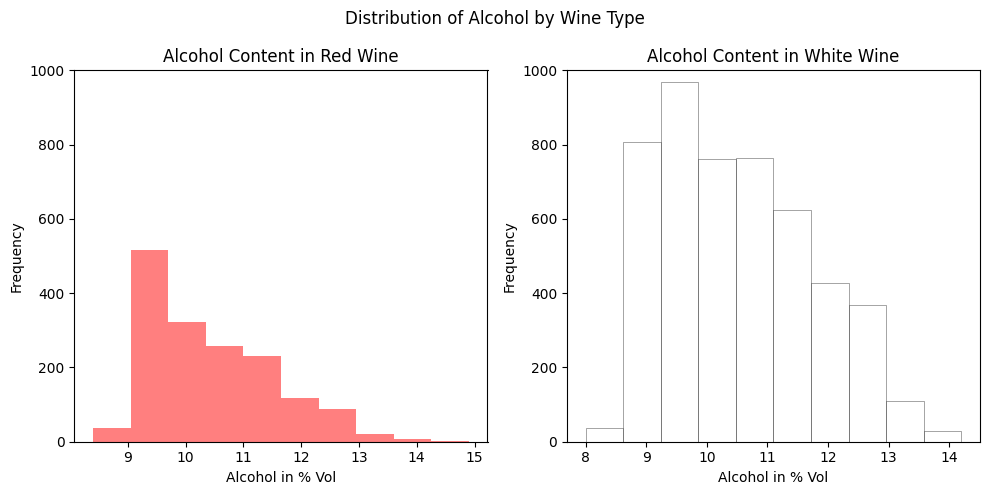

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [6]:
X = wines.iloc[:, :-1]
y = wines['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=45)

In [7]:
model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(9, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\raymo\Documents\DEAI_portfolio\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9083 - loss: 0.6203
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9375 - loss: 0.1795
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9478 - loss: 0.1461


In [10]:
y_pred = model.predict(X_test)

y_pred_labels = (y_pred >= 0.5).astype(int)

for prediction in y_pred_labels[:12]:
    wine_type = "Red wine" if prediction == 1 else "White wine"
    print(f"Prediction: {wine_type}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: Red wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine


In [11]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9624264373019465


In [12]:
from keras.optimizers import Adam
import itertools

# Define parameter options
hidden_layers_options = [1, 2]
nodes_options = [8, 16]
epochs_options = [10, 50]
lr_options = [0.001, 0.01]
batch_size_options = [32]

# Generate all combinations
param_combinations = list(itertools.product(hidden_layers_options, nodes_options, epochs_options, lr_options, batch_size_options))

results = []

for hidden_layers, nodes, epochs, lr, batch_size in param_combinations:
    # Build model
    model = Sequential()
    model.add(Dense(nodes, activation='relu', input_dim=12))
    for _ in range(hidden_layers - 1):
        model.add(Dense(nodes, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = Adam(learning_rate=lr)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    # Train
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    
    # Evaluate
    y_pred = model.predict(X_test, verbose=0)
    y_pred_labels = (y_pred >= 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred_labels)
    
    results.append({
        'hidden_layers': hidden_layers,
        'nodes': nodes,
        'epochs': epochs,
        'learning_rate': lr,
        'batch_size': batch_size,
        'accuracy': accuracy
    })

# Create DataFrame
results_df = pd.DataFrame(results)
print(results_df)

c:\Users\raymo\Documents\DEAI_portfolio\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\raymo\Documents\DEAI_portfolio\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\raymo\Documents\DEAI_portfolio\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

    hidden_layers  nodes  epochs  learning_rate  batch_size  accuracy
0               1      8      10          0.001          32  0.958352
1               1      8      10          0.010          32  0.975102
2               1      8      50          0.001          32  0.974649
3               1      8      50          0.010          32  0.939792
4               1     16      10          0.001          32  0.950204
5               1     16      10          0.010          32  0.973744
6               1     16      50          0.001          32  0.980987
7               1     16      50          0.010          32  0.981892
8               2      8      10          0.001          32  0.947488
9               2      8      10          0.010          32  0.976007
10              2      8      50          0.001          32  0.978723
11              2      8      50          0.010          32  0.981440
12              2     16      10          0.001          32  0.942055
13              2   

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# For hidden_layers=1
df1 = results_df[results_df['hidden_layers'] == 1]
for nodes in df1['nodes'].unique():
    for lr in df1['learning_rate'].unique():
        subset = df1[(df1['nodes'] == nodes) & (df1['learning_rate'] == lr)]
        axes[0, 0].plot(subset['epochs'], subset['accuracy'], marker='o', label=f'nodes={nodes}, lr={lr}')
axes[0, 0].set_title('Hidden Layers=1')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# For hidden_layers=2
df2 = results_df[results_df['hidden_layers'] == 2]
for nodes in df2['nodes'].unique():
    for lr in df2['learning_rate'].unique():
        subset = df2[(df2['nodes'] == nodes) & (df2['learning_rate'] == lr)]
        axes[0, 1].plot(subset['epochs'], subset['accuracy'], marker='o', label=f'nodes={nodes}, lr={lr}')
axes[0, 1].set_title('Hidden Layers=2')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# For epochs=10
df10 = results_df[results_df['epochs'] == 10]
for hl in df10['hidden_layers'].unique():
    for nodes in df10['nodes'].unique():
        subset = df10[(df10['hidden_layers'] == hl) & (df10['nodes'] == nodes)]
        axes[1, 0].plot(subset['learning_rate'], subset['accuracy'], marker='o', label=f'hl={hl}, nodes={nodes}')
axes[1, 0].set_title('Epochs=10')
axes[1, 0].set_xlabel('Learning Rate')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()

# For epochs=50
df50 = results_df[results_df['epochs'] == 50]
for hl in df50['hidden_layers'].unique():
    for nodes in df50['nodes'].unique():
        subset = df50[(df50['hidden_layers'] == hl) & (df50['nodes'] == nodes)]
        axes[1, 1].plot(subset['learning_rate'], subset['accuracy'], marker='o', label=f'hl={hl}, nodes={nodes}')
axes[1, 1].set_title('Epochs=50')
axes[1, 1].set_xlabel('Learning Rate')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()